# 02 — Event Sampling and Fractional Differencing

Two AFML ideas that do most of the work before any model is fitted.

**Event sampling (ch. 2).** Most bars carry no information. Training on all of them
teaches the model the unconditional distribution — mostly noise — and buries the
handful of bars where something happened. A CUSUM filter keeps only the bars where
cumulative drift has run far enough to be worth a decision.

**Fractional differencing (ch. 5).** Price levels are non-stationary, so a model
fitted on them will not generalise. The reflexive fix is to difference once and model
returns, which does achieve stationarity — and throws away every bit of level
information in the process. Fractional `d` between 0 and 1 buys stationarity at the
smallest possible cost in memory.

By the end you have an event-sampled, stationary, leak-checked feature matrix with
triple-barrier labels and AFML sample weights — the input to notebook 03.

In [1]:
import logging, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from afml_india.research import (
    Snapshot, find_snapshot, build_bars,
    sample_events, cusum_filter, get_daily_vol,
    frac_diff_ffd, get_weights_ffd, fracdiff_scan, min_ffd_order,
    triple_barrier_labels, get_av_uniqueness_from_triple_barrier,
    get_sadf, NSE,
)
from afml_india.features import FeatureConfig, assert_no_lookahead

warnings.filterwarnings("ignore")
logging.getLogger("afml_india").setLevel(logging.WARNING)
pd.set_option("display.width", 120, "display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

In [2]:
snap = Snapshot(find_snapshot())
symbol = snap.most_liquid(1)[0]
ticks = snap.ticks(symbol, kind="trades")
bars = build_bars(ticks, kind="dollar", bars_per_day=50)
close = bars["close"].astype(float)

print(f"{symbol}: {len(bars):,} rupee bars over {bars.index.normalize().nunique()} sessions")
if snap.is_synthetic:
    print("\n*** SYNTHETIC DATA — mechanics are real, conclusions are not. ***")

ICICIBC_IN: 3,212 rupee bars over 65 sessions

*** SYNTHETIC DATA — mechanics are real, conclusions are not. ***


## 1. CUSUM event sampling

The symmetric CUSUM filter accumulates signed changes and fires when the running sum
breaches a threshold in either direction, resetting on each fire. Unlike a
Bollinger-style rule it will not fire repeatedly while a series hovers at a level —
it needs a sustained run.

### The trap: it must run on log prices

`cusum_filter` accumulates the **first difference of whatever series you hand it**.
Give it rupee prices and the running sum is denominated in rupees, so a return-scale
threshold like 0.02 is breached within a bar or two and effectively every bar becomes
an event. The cell below shows how badly that fails.

In [3]:
vol = get_daily_vol(close, lookback=50).dropna()
threshold = float(vol.median())
print(f"Median trailing daily vol: {threshold:.4f}  ({threshold * 100:.2f}%)")

wrong = cusum_filter(close, threshold=threshold)              # raw rupee prices
right = cusum_filter(np.log(close), threshold=threshold)      # log prices

print(f"\nOn raw prices : {len(wrong):>5} events from {len(close)} bars "
      f"({100 * len(wrong) / len(close):.1f}%)  <- broken")
print(f"On log prices : {len(right):>5} events from {len(close)} bars "
      f"({100 * len(right) / len(close):.1f}%)  <- correct")
print("\nsample_events() applies the log transform for you.")

Median trailing daily vol: 0.0328  (3.28%)

On raw prices :  3195 events from 3212 bars (99.5%)  <- broken
On log prices :   243 events from 3212 bars (7.6%)  <- correct

sample_events() applies the log transform for you.


### Choosing the threshold

The threshold is a real modelling decision, not a default to accept. Too low and you
are back to training on every bar; too high and there is nothing to learn from.
Scaling by trailing volatility keeps the event rate stable as the regime changes,
which matters across an Indian cross-section where volatility varies several-fold
between an IT major and a PSU bank.

In [4]:
rows = []
for multiple in [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]:
    events = sample_events(close, vol_multiple=multiple, vol_lookback=50)
    gaps = np.diff(events.get_indexer(events)) if len(events) > 1 else np.array([np.nan])
    spacing = np.diff(close.index.get_indexer(events)) if len(events) > 1 else np.array([np.nan])
    rows.append({
        "vol_multiple": multiple,
        "events": len(events),
        "pct_of_bars": 100 * len(events) / len(close),
        "events_per_day": len(events) / close.index.normalize().nunique(),
        "median_gap_bars": float(np.median(spacing)) if len(events) > 1 else np.nan,
    })
sweep = pd.DataFrame(rows)
sweep.round(2)

,vol_multiple,events,pct_of_bars,events_per_day,median_gap_bars
0,0.50,653,20.33,10.05,4.0
1,0.75,389,12.11,5.98,7.0
2,1.00,243,7.57,3.74,11.0
3,1.50,128,3.99,1.97,23.0
4,2.00,76,2.37,1.17,36.0
5,3.00,37,1.15,0.57,75.0
6,4.00,18,0.56,0.28,169.0


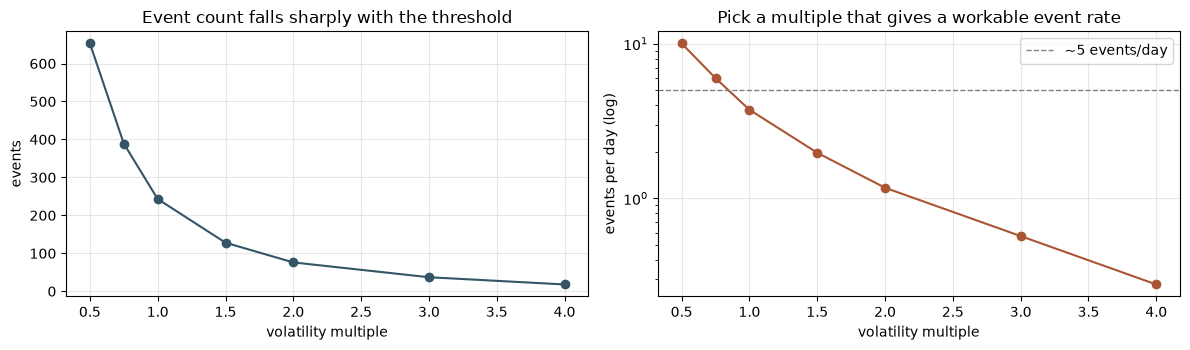

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.6))
ax1.plot(sweep["vol_multiple"], sweep["events"], "o-", color="#356")
ax1.set_xlabel("volatility multiple"); ax1.set_ylabel("events")
ax1.set_title("Event count falls sharply with the threshold")
ax2.semilogy(sweep["vol_multiple"], sweep["events_per_day"], "o-", color="#a53")
ax2.axhline(5, ls="--", c="grey", lw=1, label="~5 events/day")
ax2.set_xlabel("volatility multiple"); ax2.set_ylabel("events per day (log)")
ax2.set_title("Pick a multiple that gives a workable event rate"); ax2.legend()
plt.tight_layout(); plt.show()

Using vol_multiple=1.0: 243 events (3.7 per session)


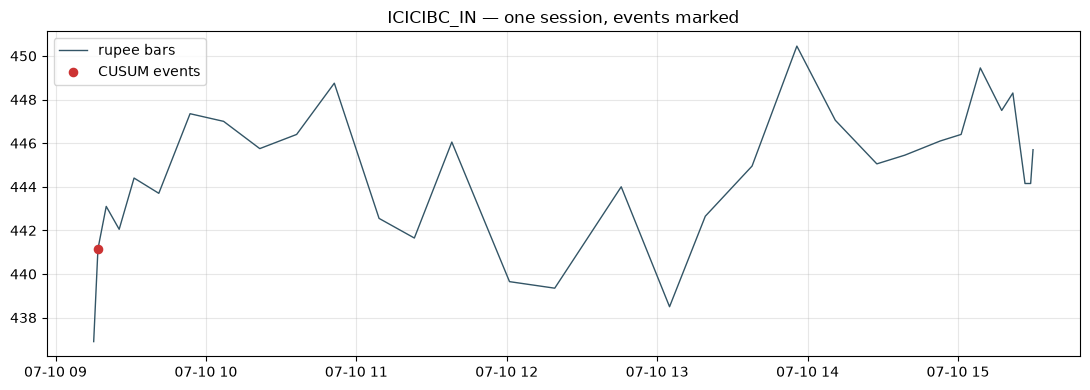

In [6]:
# Settle on a multiple giving a few events per session, then look at where they land.
VOL_MULTIPLE = float(sweep.loc[(sweep["events_per_day"] - 4).abs().idxmin(), "vol_multiple"])
events = sample_events(close, vol_multiple=VOL_MULTIPLE, vol_lookback=50)
print(f"Using vol_multiple={VOL_MULTIPLE}: {len(events)} events "
      f"({len(events) / close.index.normalize().nunique():.1f} per session)")

one_day = close.index.normalize() == close.index.normalize()[len(close) // 2]
fig, ax = plt.subplots()
ax.plot(close[one_day].index, close[one_day].to_numpy(), lw=1, color="#356", label="rupee bars")
day_events = events[events.isin(close[one_day].index)]
ax.scatter(day_events, close.loc[day_events], color="#c33", zorder=5, s=35, label="CUSUM events")
ax.set_title(f"{symbol} — one session, events marked"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Fractional differencing

The AFML weight sequence is `w_k = -w_{k-1} * (d - k + 1) / k` with `w_0 = 1`. For
integer `d = 1` it terminates after two terms — the familiar first difference. For
fractional `d` it decays but never terminates, which is precisely why memory survives:
every past observation still contributes, with a weight that fades.

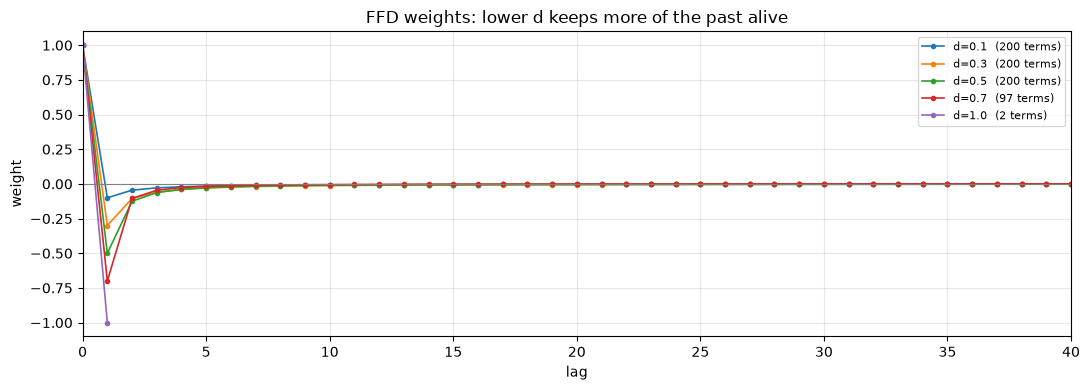

Window length required at thresh=1e-4:
  d=0.1:  503 terms
  d=0.3:  388 terms
  d=0.5:  200 terms
  d=0.7:   97 terms
  d=1.0:    2 terms


In [7]:
fig, ax = plt.subplots()
for d in [0.1, 0.3, 0.5, 0.7, 1.0]:
    w = get_weights_ffd(d, 1e-4, 200).ravel()[::-1]  # newest first
    ax.plot(range(len(w)), w, marker="o", ms=3, lw=1.2, label=f"d={d}  ({len(w)} terms)")
ax.set_xlabel("lag"); ax.set_ylabel("weight"); ax.set_xlim(0, 40)
ax.axhline(0, c="grey", lw=0.8)
ax.set_title("FFD weights: lower d keeps more of the past alive")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Window length required at thresh=1e-4:")
for d in [0.1, 0.3, 0.5, 0.7, 1.0]:
    print(f"  d={d}: {len(get_weights_ffd(d, 1e-4, 10_000)):>4} terms")

### Scanning for the minimum passing `d`

The scan reports, for each `d`, the ADF statistic (stationarity) and the correlation
to the undifferenced series (memory). The useful `d` is the **smallest** one that
clears the stationarity test — anything beyond it destroys memory for nothing.

Read `n_obs` alongside the statistics. Fixed-width differencing discards a leading
warm-up window that grows as `d` shrinks, so the rows are not computed on equal
samples; `min_ffd_order` enforces a floor via `min_obs` for that reason.

In [8]:
scan = fracdiff_scan(close, thresh=1e-4, max_order=1.0, step=0.05)
scan.round(4)

,d,adf_stat,adf_pvalue,crit_5pct,corr,n_obs
0,0.00,-2.4787,0.1207,-2.8624,1.0000,3210
1,0.05,-3.4229,0.0102,-2.8626,0.9962,2849
2,0.10,-4.7897,0.0001,-2.8626,0.9733,2708
3,0.15,-5.7319,0.0000,-2.8626,0.9352,2684
4,0.20,-6.9159,0.0000,-2.8626,0.8849,2714
5,0.25,-8.0074,0.0000,-2.8626,0.8395,2766
6,0.30,-9.2968,0.0000,-2.8626,0.7916,2823
7,0.35,-10.8159,0.0000,-2.8625,0.7384,2879
8,0.40,-12.6675,0.0000,-2.8625,0.6742,2929
9,0.45,-14.8813,0.0000,-2.8625,0.5997,2973


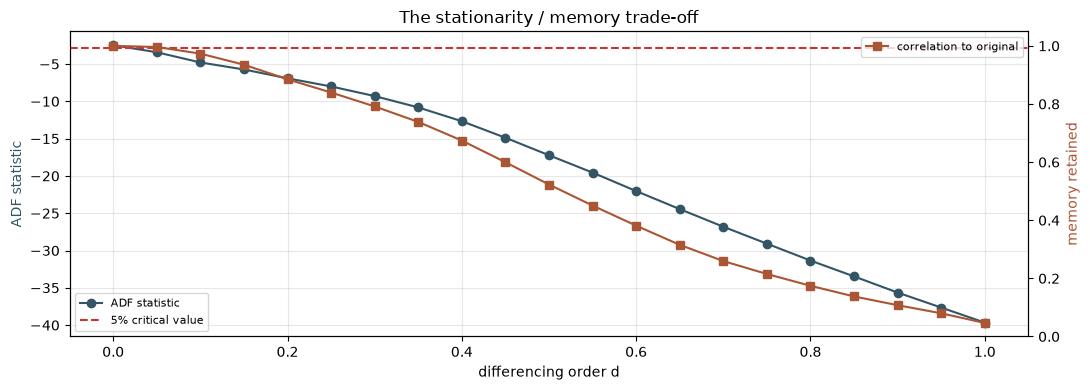

In [9]:
fig, ax1 = plt.subplots()
ax1.plot(scan["d"], scan["adf_stat"], "o-", color="#356", label="ADF statistic")
ax1.axhline(scan["crit_5pct"].mean(), ls="--", c="#c33", label="5% critical value")
ax1.set_xlabel("differencing order d"); ax1.set_ylabel("ADF statistic", color="#356")
ax1.legend(loc="lower left", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(scan["d"], scan["corr"], "s-", color="#a53", label="correlation to original")
ax2.set_ylabel("memory retained", color="#a53"); ax2.set_ylim(0, 1.05)
ax2.grid(False); ax2.legend(loc="upper right", fontsize=8)
ax1.set_title("The stationarity / memory trade-off")
plt.tight_layout(); plt.show()

In [10]:
best = min_ffd_order(close, thresh=1e-4, max_order=1.0, step=0.05, min_obs=100)
D = best["d"]
full_diff = scan.loc[scan["d"].sub(1.0).abs().idxmin()]

print(f"Minimum passing d : {D}")
print(f"  ADF p-value     : {best['adf_pvalue']:.6f}")
print(f"  memory retained : {best['corr']:.1%}")
print(f"  observations    : {best['n_obs']}")
print(f"\nFor comparison, d=1.0 (plain returns) retains {full_diff['corr']:.1%} of the memory.")
print(f"Fractional differencing keeps {best['corr'] / max(full_diff['corr'], 1e-9):.0f}x more.")

Minimum passing d : 0.05
  ADF p-value     : 0.010204
  memory retained : 99.6%
  observations    : 2849

For comparison, d=1.0 (plain returns) retains 4.7% of the memory.
Fractional differencing keeps 21x more.


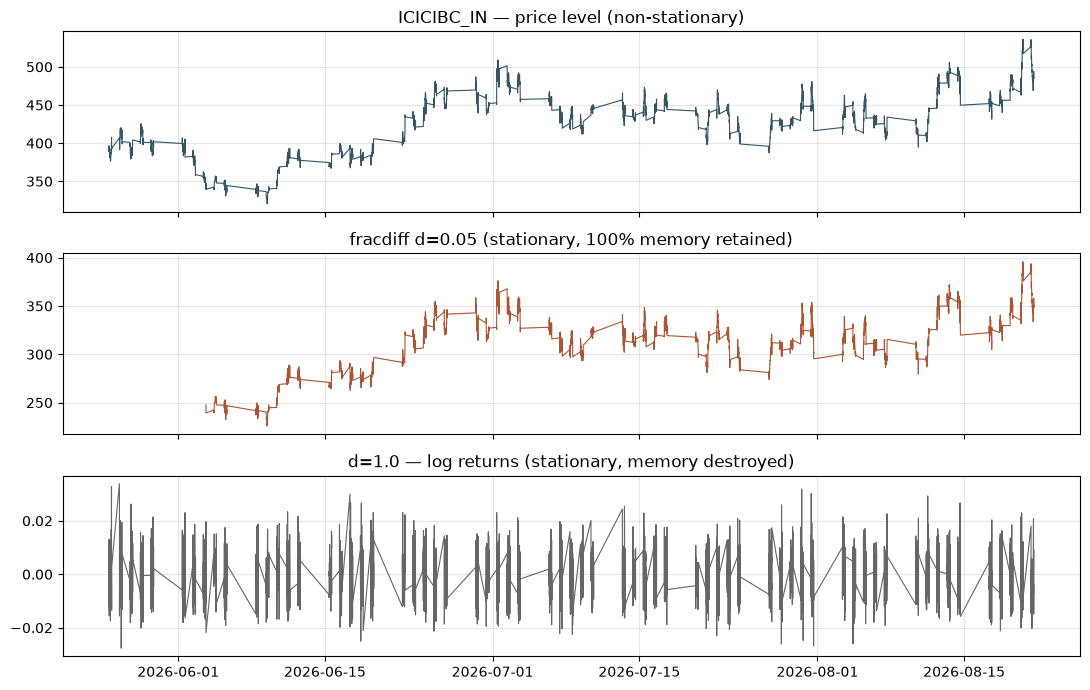

In [11]:
fd = frac_diff_ffd(close.to_frame("close"), diff_amt=D, thresh=1e-4)["close"].dropna()

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(close.index, close.to_numpy(), lw=0.8, color="#356")
axes[0].set_title(f"{symbol} — price level (non-stationary)")
axes[1].plot(fd.index, fd.to_numpy(), lw=0.8, color="#a53")
axes[1].set_title(f"fracdiff d={D} (stationary, {best['corr']:.0%} memory retained)")
rets = np.log(close).diff().dropna()
axes[2].plot(rets.index, rets.to_numpy(), lw=0.8, color="#666")
axes[2].set_title("d=1.0 — log returns (stationary, memory destroyed)")
plt.tight_layout(); plt.show()

## 3. Structural breaks — an alternative event trigger

CUSUM fires on cumulative drift. The SADF test fires on **explosive** behaviour, which
is a different and often more interesting event: bubble onset, a squeeze, a regime
change. Worth having in the toolbox as a second sampler to compare against.

SADF computed over 761 points


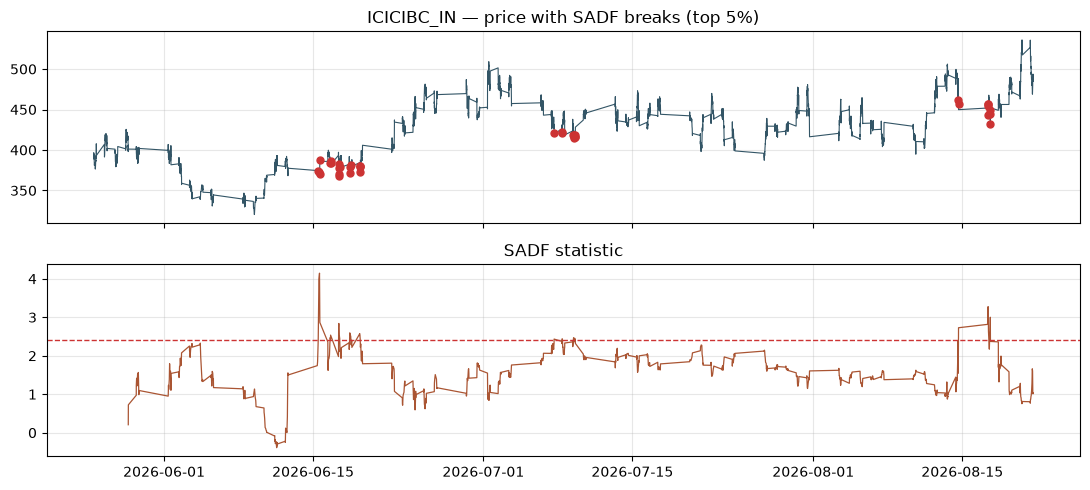

38 break points flagged


In [12]:
# SADF is O(n^2) in the series length; subsample so this stays quick.
sub = np.log(close).iloc[::4]
try:
    sadf = get_sadf(sub, model="linear", lags=2, min_length=40, verbose=False).dropna()
    print(f"SADF computed over {len(sadf)} points")
    cutoff = float(sadf.quantile(0.95))
    breaks = sadf[sadf > cutoff].index

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    a1.plot(close.index, close.to_numpy(), lw=0.8, color="#356")
    a1.scatter(breaks, close.reindex(breaks).to_numpy(), c="#c33", s=25, zorder=5)
    a1.set_title(f"{symbol} — price with SADF breaks (top 5%)")
    a2.plot(sadf.index, sadf.to_numpy(), lw=0.9, color="#a53")
    a2.axhline(cutoff, ls="--", c="#c33", lw=1)
    a2.set_title("SADF statistic")
    plt.tight_layout(); plt.show()
    print(f"{len(breaks)} break points flagged")
except Exception as exc:
    print(f"SADF skipped: {exc}")

## 4. Triple-barrier labels

Three barriers: a profit target, a stop, and a time limit. The label is whichever is
touched first. This is a far better target than a fixed-horizon return because it
encodes the path — a position that would have been stopped out on day two is labelled
a loss even if the price recovered by day five.

Barrier widths are set as multiples of trailing volatility, so they mean the same
thing across regimes and across names.

**The vertical barrier must count trading sessions, not calendar days.** fin-kit's
`add_vertical_barrier` counts calendar days, which silently shortens the holding
period across Diwali or a long weekend. `triple_barrier_labels` routes it through the
NSE calendar.

In [13]:
HOLDING_DAYS = 2

labels = triple_barrier_labels(
    close, events=events, pt_sl=(1.0, 1.0),
    num_days=HOLDING_DAYS, vol_lookback=50,
)
labels = labels[labels["bin"] != 0]

print(f"{len(labels)} labels from {len(events)} events")
print(f"\nClass balance:\n{labels['bin'].value_counts().sort_index().to_string()}")
print(f"\nMean return by label:")
print(labels.groupby("bin")["ret"].agg(["mean", "std", "count"]).round(4).to_string())
labels.head()

226 labels from 243 events

Class balance:
bin
-1.0    115
 1.0    111

Mean return by label:
        mean     std  count
bin                        
-1.0 -0.0382  0.0118    115
 1.0  0.0378  0.0115    111


,ret,bin,t1
timestamp,,,
2026-05-26 09:32:44.207253488+05:30,0.016739,1.0,2026-05-26 10:09:49.837161438+05:30
2026-05-26 10:43:04.981511952+05:30,0.024007,1.0,2026-05-26 13:07:30.140720167+05:30
2026-05-26 14:02:35.365289211+05:30,-0.047883,-1.0,2026-05-27 10:13:10.682420312+05:30
2026-05-26 15:26:03.311282282+05:30,-0.045646,-1.0,2026-05-27 10:13:10.682420312+05:30
2026-05-27 10:13:10.682420312+05:30,0.042126,1.0,2026-05-27 15:26:35.885966307+05:30


In [14]:
# How the calendar changes the barrier: the same shift, with and without sessions.
naive_t1 = events + pd.Timedelta(days=HOLDING_DAYS)
session_t1 = NSE.add_sessions(events, HOLDING_DAYS)
differs = (naive_t1.normalize() != session_t1.normalize()).sum()
print(f"{differs} of {len(events)} vertical barriers land on a different day "
      f"({100 * differs / len(events):.0f}%) once holidays and weekends are respected.")

115 of 243 vertical barriers land on a different day (47%) once holidays and weekends are respected.


## 5. Sample weights — labels are not independent draws

A label at bar `t` spans until its barrier is touched. With 50 bars a day and a
two-session horizon, each label overlaps roughly a hundred others. Treating them as
independent observations inflates the effective sample size by two orders of
magnitude, and every model and every cross-validation score inherits that error.

Average uniqueness measures how much of each label's lifespan is *not* shared.

Mean average uniqueness : 0.6155
Effective sample size   : 139 of 226 labels (61.5%)


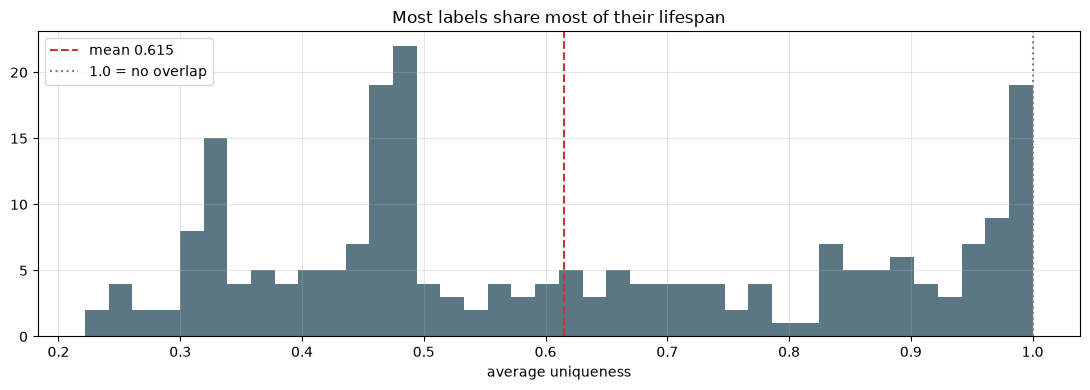

In [15]:
weights = get_av_uniqueness_from_triple_barrier(
    labels[["t1"]].dropna(), close, num_threads=1, verbose=False
)
# fin-kit returns a Series here; some mlfinlab releases return a frame with 'tW'.
if isinstance(weights, pd.DataFrame):
    weights = weights["tW"] if "tW" in weights.columns else weights.iloc[:, 0]

print(f"Mean average uniqueness : {weights.mean():.4f}")
print(f"Effective sample size   : {weights.sum():.0f} of {len(weights)} labels "
      f"({100 * weights.sum() / len(weights):.1f}%)")

fig, ax = plt.subplots()
ax.hist(weights.dropna(), bins=40, color="#356", alpha=0.8)
ax.axvline(weights.mean(), c="#c33", ls="--", label=f"mean {weights.mean():.3f}")
ax.axvline(1.0, c="grey", ls=":", label="1.0 = no overlap")
ax.set_xlabel("average uniqueness"); ax.set_title("Most labels share most of their lifespan")
ax.legend()
plt.tight_layout(); plt.show()

## 6. The feature matrix, and a check that nothing leaks

`FeatureConfig` assembles fracdiff, momentum, range-volatility, order-flow and
session-position blocks. Every one is strictly backward-looking.

`assert_no_lookahead` verifies that claim rather than asserting it: it rebuilds the
features on truncated history at several cut points and checks the last surviving row
is unchanged. A feature that peeks at the future changes when the future is removed.

In [16]:
config = FeatureConfig(d=D, fracdiff_thresh=1e-4)
features = config.build(bars)
print(f"Feature matrix: {features.shape[0]:,} rows x {features.shape[1]} features")
print(f"Warm-up cost  : {len(bars) - len(features):,} bars dropped")
print()
print(pd.Series(features.columns).to_string())

Feature matrix: 2,851 rows x 30 features
Warm-up cost  : 361 bars dropped

0                  ret_5
1                  vol_5
2                 zmom_5
3                 ret_20
4                 vol_20
5                zmom_20
6                 ret_50
7                 vol_50
8                zmom_50
9                  ret_1
10              fd_close
11             fd_volume
12          parkinson_20
13       garman_klass_20
14          vol_ratio_20
15          parkinson_50
16       garman_klass_50
17          vol_ratio_50
18             buy_share
19       order_imbalance
20    order_imbalance_20
21    order_imbalance_50
22             log_ticks
23        avg_trade_size
24             amihud_20
25             amihud_50
26      session_progress
27           session_sin
28           session_cos
29           day_of_week


In [17]:
assert_no_lookahead(config, bars, n_checks=10)
print("Look-ahead check PASSED — no feature changes when future bars are removed.")

Look-ahead check PASSED — no feature changes when future bars are removed.


In [18]:
labelled = features.join(labels[["bin"]], how="inner").dropna(subset=["bin"])
print(f"Model-ready samples: {len(labelled):,}")
print(f"Class balance      : {labelled['bin'].value_counts(normalize=True).round(3).to_dict()}")

corr = labelled.drop(columns=["bin"]).corrwith(labelled["bin"]).abs().sort_values(ascending=False)
print("\nTop |correlation| with the label:")
print(corr.head(10).round(4).to_string())
print("\nThese are tiny by design — if any single feature correlated strongly with a")
print("forward-looking label, that would be evidence of a leak, not of alpha.")

Model-ready samples: 204
Class balance      : {-1.0: 0.5, 1.0: 0.5}

Top |correlation| with the label:
log_ticks             0.1859
fd_volume             0.1511
fd_close              0.1440
vol_ratio_20          0.1408
day_of_week           0.1282
avg_trade_size        0.1147
zmom_50               0.1045
ret_50                0.0998
order_imbalance_20    0.0997
vol_5                 0.0976

These are tiny by design — if any single feature correlated strongly with a
forward-looking label, that would be evidence of a leak, not of alpha.


## Takeaways

1. **CUSUM must run on log prices.** On raw rupee prices the threshold is in the
   wrong units and nearly every bar becomes an event. `sample_events` handles it.

2. **The threshold is a modelling choice.** Scale it by trailing volatility and
   target a workable event rate rather than accepting a default.

3. **Fractional differencing dominates first differencing.** At the minimum passing
   `d` this series stays stationary while retaining a large multiple of the memory
   that plain returns keep. That is free information.

4. **Barriers must respect the exchange calendar.** A meaningful fraction of vertical
   barriers land on a different day once NSE holidays are accounted for.

5. **Overlapping labels are the silent killer.** The effective sample here is a small
   fraction of the nominal row count. Every model and every CV score must be weighted
   accordingly.

Next: **`03_lstm_fracdiff_comparator.ipynb`** — hold the model fixed and vary only the
input representation, to isolate what fractional differencing actually buys.